In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
!git clone https://github.com/MTG/mtg-jamendo-dataset.git

Cloning into 'mtg-jamendo-dataset'...
remote: Enumerating objects: 1283, done.
remote: Counting objects: 100% (253/253), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 1283 (delta 241), reused 224 (delta 224), pack-reused 1030 (from 1)
Receiving objects: 100% (1283/1283), 42.37 MiB | 28.22 MiB/s, done.
Resolving deltas: 100% (787/787), done.


In [ ]:
from pathlib import Path
import pandas as pd

# I talked through writing this code block with ChatGPT 5. pandas had trouble reading the tsv because there were more
# than 1 tag per song, so pandas expected 6 columns and would receive 7 or 8
# depending on the number of multiple tags
def read_mtg(relative_path: str, root: str | Path = "mtg-jamendo-dataset") -> pd.DataFrame:
    """
    Minimal reader for MTG-Jamendo TSVs where cols 1–5 are scalars and the rest are TAGS.
    Always skips the first line (header).
    """
    file_path = Path(root) / relative_path
    cols = ["TRACK_ID", "ARTIST_ID", "ALBUM_ID", "PATH", "DURATION", "TAGS"]
    data = []


    with open(file_path, "r", encoding="utf-8") as f:
        next(f, None)  # skip the header row
        for line in f:
            parts = line.rstrip("\n").split("\t") # split each line by tab delimiter after removing newline character
            if len(parts) < 5:
                continue # skip lines that don't have at least the first 5 expected columns
            # first 5 parts are fixed columns, and rest are joined back into single 'TAGS' string
            data.append(parts[:5] + ["\t".join(parts[5:])])

    return pd.DataFrame(data, columns=cols)


In [ ]:
auto = read_mtg("data/autotagging.tsv")
print(auto.shape)
auto.head(10)

(55609, 6)


,TRACK_ID,ARTIST_ID,ALBUM_ID,PATH,DURATION,TAGS
0,track_0000214,artist_000014,album_000031,14/214.mp3,124.6,genre---punkrock
1,track_0000215,artist_000014,album_000031,15/215.mp3,151.4,genre---metal
2,track_0000216,artist_000014,album_000031,16/216.mp3,234.9,genre---metal
3,track_0000217,artist_000014,album_000031,17/217.mp3,127.9,genre---punkrock
4,track_0000218,artist_000014,album_000031,18/218.mp3,180.7,genre---punkrock
5,track_0000219,artist_000014,album_000031,19/219.mp3,199.4,genre---metal
6,track_0000220,artist_000014,album_000031,20/220.mp3,174.3,genre---punkrock
7,track_0000221,artist_000014,album_000031,21/221.mp3,224.6,genre---punkrock
8,track_0000222,artist_000014,album_000031,22/222.mp3,161.9,genre---punkrock
9,track_0000223,artist_000014,album_000031,23/223.mp3,217.9,genre---metal


In [ ]:
genre = read_mtg("data/autotagging_genre.tsv")
print(genre.shape)
# split the tags again after we combining them to preserve the pd data structure
# For songs with multiple tags, we joined them so they all fit in the single 'TAGS' column
unique_tags_genre = pd.unique(
    genre["TAGS"].str.split("\t").explode().dropna().loc[lambda s: s != ""]
)
print(unique_tags_genre)
genre.head(10)

(55215, 6)
['genre---punkrock' 'genre---metal' 'genre---rock' 'genre---pop'
 'genre---classical' 'genre---popfolk' 'genre---electronic'
 'genre---easylistening' 'genre---lounge' 'genre---disco' 'genre---funk'
 'genre---rnb' 'genre---ambient' 'genre---chillout' 'genre---downtempo'
 'genre---triphop' 'genre---breakbeat' 'genre---techno' 'genre---newage'
 'genre---jazz' 'genre---industrial' 'genre---instrumentalrock'
 'genre---minimal' 'genre---alternative' 'genre---experimental'
 'genre---poprock' 'genre---ska' 'genre---drumnbass' 'genre---soul'
 'genre---fusion' 'genre---soundtrack' 'genre---electropop'
 'genre---world' 'genre---ethno' 'genre---trance' 'genre---orchestral'
 'genre---instrumentalpop' 'genre---worldfusion' 'genre---grunge'
 'genre---folk' 'genre---chanson' 'genre---house' 'genre---dub'
 'genre---hiphop' 'genre---groove' 'genre---postrock' 'genre---dance'
 'genre---blues' 'genre---improvisation' 'genre---progressive'
 'genre---reggae' 'genre---contemporary' 'genre---indie'

,TRACK_ID,ARTIST_ID,ALBUM_ID,PATH,DURATION,TAGS
0,track_0000214,artist_000014,album_000031,14/214.mp3,124.6,genre---punkrock
1,track_0000215,artist_000014,album_000031,15/215.mp3,151.4,genre---metal
2,track_0000216,artist_000014,album_000031,16/216.mp3,234.9,genre---metal
3,track_0000217,artist_000014,album_000031,17/217.mp3,127.9,genre---punkrock
4,track_0000218,artist_000014,album_000031,18/218.mp3,180.7,genre---punkrock
5,track_0000219,artist_000014,album_000031,19/219.mp3,199.4,genre---metal
6,track_0000220,artist_000014,album_000031,20/220.mp3,174.3,genre---punkrock
7,track_0000221,artist_000014,album_000031,21/221.mp3,224.6,genre---punkrock
8,track_0000222,artist_000014,album_000031,22/222.mp3,161.9,genre---punkrock
9,track_0000223,artist_000014,album_000031,23/223.mp3,217.9,genre---metal


In [ ]:
instr = read_mtg("data/autotagging_instrument.tsv")
print(instr.shape)
unique_tags_instr = pd.unique(
    instr["TAGS"].str.split("\t").explode().dropna().loc[lambda s: s != ""]
)
print(unique_tags_instr)
instr.head(10)

(25135, 6)
['instrument---voice' 'instrument---synthesizer' 'instrument---piano'
 'instrument---strings' 'instrument---beat' 'instrument---guitar'
 'instrument---cello' 'instrument---keyboard' 'instrument---trombone'
 'instrument---clarinet' 'instrument---doublebass' 'instrument---horn'
 'instrument---trumpet' 'instrument---violin' 'instrument---accordion'
 'instrument---bass' 'instrument---computer' 'instrument---drummachine'
 'instrument---drums' 'instrument---electricguitar' 'instrument---sampler'
 'instrument---acousticguitar' 'instrument---harmonica'
 'instrument---flute' 'instrument---classicalguitar'
 'instrument---pipeorgan' 'instrument---saxophone' 'instrument---rhodes'
 'instrument---acousticbassguitar' 'instrument---oboe' 'instrument---harp'
 'instrument---percussion' 'instrument---electricpiano'
 'instrument---orchestra' 'instrument---viola' 'instrument---ukulele'
 'instrument---bongo' 'instrument---brass' 'instrument---organ'
 'instrument---bell' 'instrument---pad']


,TRACK_ID,ARTIST_ID,ALBUM_ID,PATH,DURATION,TAGS
0,track_0000382,artist_000020,album_000046,82/382.mp3,211.1,instrument---voice
1,track_0000383,artist_000020,album_000046,83/383.mp3,113.1,instrument---voice
2,track_0000384,artist_000020,album_000046,84/384.mp3,115.7,instrument---voice
3,track_0000386,artist_000020,album_000046,86/386.mp3,103.4,instrument---voice
4,track_0000387,artist_000020,album_000046,87/387.mp3,257.1,instrument---voice
5,track_0000388,artist_000020,album_000046,88/388.mp3,124.6,instrument---voice
6,track_0000389,artist_000020,album_000046,89/389.mp3,150.8,instrument---voice
7,track_0000390,artist_000020,album_000046,90/390.mp3,133.7,instrument---voice
8,track_0000391,artist_000020,album_000046,91/391.mp3,82.1,instrument---voice
9,track_0000392,artist_000020,album_000046,92/392.mp3,127.3,instrument---voice


In [ ]:
mood = read_mtg("data/autotagging_moodtheme.tsv")
print(mood.shape)
unique_tags_mood = pd.unique(
    mood["TAGS"].str.split("\t").explode().dropna().loc[lambda s: s != ""]
)
print(unique_tags_mood)
mood.head(10)

(18486, 6)
['mood/theme---background' 'mood/theme---film' 'mood/theme---melancholic'
 'mood/theme---calm' 'mood/theme---melodic' 'mood/theme---children'
 'mood/theme---relaxing' 'mood/theme---meditative' 'mood/theme---cool'
 'mood/theme---documentary' 'mood/theme---emotional' 'mood/theme---space'
 'mood/theme---love' 'mood/theme---drama' 'mood/theme---adventure'
 'mood/theme---heavy' 'mood/theme---dark' 'mood/theme---soft'
 'mood/theme---energetic' 'mood/theme---retro' 'mood/theme---ballad'
 'mood/theme---advertising' 'mood/theme---epic' 'mood/theme---action'
 'mood/theme---dramatic' 'mood/theme---powerful' 'mood/theme---upbeat'
 'mood/theme---inspiring' 'mood/theme---uplifting'
 'mood/theme---soundscape' 'mood/theme---slow' 'mood/theme---deep'
 'mood/theme---fun' 'mood/theme---horror' 'mood/theme---nature'
 'mood/theme---funny' 'mood/theme---happy' 'mood/theme---positive'
 'mood/theme---sad' 'mood/theme---summer' 'mood/theme---dream'
 'mood/theme---romantic' 'mood/theme---hopeful' 'mo

,TRACK_ID,ARTIST_ID,ALBUM_ID,PATH,DURATION,TAGS
0,track_0000948,artist_000087,album_000149,48/948.mp3,212.7,mood/theme---background
1,track_0000950,artist_000087,album_000149,50/950.mp3,248.0,mood/theme---background
2,track_0000951,artist_000087,album_000149,51/951.mp3,199.7,mood/theme---background
3,track_0002165,artist_000326,album_000347,65/2165.mp3,229.0,mood/theme---film
4,track_0002263,artist_000320,album_000366,63/2263.mp3,494.7,mood/theme---melancholic
5,track_0003346,artist_000517,album_000521,46/3346.mp3,195.0,mood/theme---calm\tmood/theme---melodic
6,track_0003347,artist_000517,album_000521,47/3347.mp3,201.8,mood/theme---calm\tmood/theme---melodic
7,track_0003348,artist_000517,album_000521,48/3348.mp3,253.3,mood/theme---calm\tmood/theme---melodic
8,track_0003349,artist_000517,album_000521,49/3349.mp3,228.4,mood/theme---calm\tmood/theme---melodic
9,track_0003350,artist_000517,album_000521,50/3350.mp3,194.7,mood/theme---calm\tmood/theme---melodic


In [ ]:
auto = read_mtg("data/autotagging.tsv")
meta = read_mtg("data/raw.meta.tsv")
auto_merged = auto.merge(meta, on="TRACK_ID")
auto_merged.head(10)


,TRACK_ID,ARTIST_ID_x,ALBUM_ID_x,PATH_x,DURATION_x,TAGS_x,ARTIST_ID_y,ALBUM_ID_y,PATH_y,DURATION_y,TAGS_y
0,track_0000214,artist_000014,album_000031,14/214.mp3,124.6,genre---punkrock,artist_000014,album_000031,Intro chiante,David TMX,Pouce !\t2004-12-28\thttp://www.jamendo.com/tr...
1,track_0000215,artist_000014,album_000031,15/215.mp3,151.4,genre---metal,artist_000014,album_000031,Aide toi...,David TMX,Pouce !\t2004-12-28\thttp://www.jamendo.com/tr...
2,track_0000216,artist_000014,album_000031,16/216.mp3,234.9,genre---metal,artist_000014,album_000031,Une charogne,David TMX,Pouce !\t2004-12-28\thttp://www.jamendo.com/tr...
3,track_0000217,artist_000014,album_000031,17/217.mp3,127.9,genre---punkrock,artist_000014,album_000031,Aimons nous...,David TMX,Pouce !\t2004-12-28\thttp://www.jamendo.com/tr...
4,track_0000218,artist_000014,album_000031,18/218.mp3,180.7,genre---punkrock,artist_000014,album_000031,Jouvencelle,David TMX,Pouce !\t2004-12-28\thttp://www.jamendo.com/tr...
5,track_0000219,artist_000014,album_000031,19/219.mp3,199.4,genre---metal,artist_000014,album_000031,L'homme pouce,David TMX,Pouce !\t2004-12-28\thttp://www.jamendo.com/tr...
6,track_0000220,artist_000014,album_000031,20/220.mp3,174.3,genre---punkrock,artist_000014,album_000031,Y'a un truc,David TMX,Pouce !\t2004-12-28\thttp://www.jamendo.com/tr...
7,track_0000221,artist_000014,album_000031,21/221.mp3,224.6,genre---punkrock,artist_000014,album_000031,LVO Hardcore,David TMX,Pouce !\t2004-12-28\thttp://www.jamendo.com/tr...
8,track_0000222,artist_000014,album_000031,22/222.mp3,161.9,genre---punkrock,artist_000014,album_000031,Que du naturel,David TMX,Pouce !\t2004-12-28\thttp://www.jamendo.com/tr...
9,track_0000223,artist_000014,album_000031,23/223.mp3,217.9,genre---metal,artist_000014,album_000031,Voici le gala,David TMX,Pouce !\t2004-12-28\thttp://www.jamendo.com/tr...


In [ ]:
auto.columns
auto['TAGS'].unique()

array(['genre---punkrock', 'genre---metal', 'genre---rock', ...,
       'genre---electropop\tgenre---indie\tgenre---synthpop',
       'genre---soundtrack\tinstrument---computer\tmood/theme---advertising\tmood/theme---dramatic\tmood/theme---epic\tmood/theme---movie',
       'genre---soundtrack\tinstrument---computer\tmood/theme---dramatic\tmood/theme---epic\tmood/theme---movie'],
      dtype=object)

In [ ]:
unique_tags = pd.unique(
    auto["TAGS"].str.split("\t").explode().dropna().loc[lambda s: s != ""]
)
print(unique_tags)

['genre---punkrock' 'genre---metal' 'genre---rock' 'genre---pop'
 'genre---classical' 'instrument---voice' 'genre---popfolk'
 'genre---electronic' 'genre---easylistening' 'genre---lounge'
 'genre---disco' 'genre---funk' 'genre---rnb' 'genre---ambient'
 'genre---chillout' 'genre---downtempo' 'instrument---synthesizer'
 'genre---triphop' 'mood/theme---background' 'genre---breakbeat'
 'genre---techno' 'genre---newage' 'genre---jazz' 'instrument---piano'
 'genre---industrial' 'genre---instrumentalrock' 'genre---minimal'
 'genre---alternative' 'genre---experimental' 'genre---poprock'
 'genre---ska' 'genre---drumnbass' 'genre---soul' 'genre---fusion'
 'genre---soundtrack' 'mood/theme---film' 'genre---electropop'
 'genre---world' 'genre---ethno' 'instrument---strings' 'genre---trance'
 'instrument---beat' 'genre---orchestral' 'genre---instrumentalpop'
 'genre---worldfusion' 'genre---grunge' 'mood/theme---melancholic'
 'genre---folk' 'genre---chanson' 'instrument---guitar'
 'mood/theme---calm'

In [ ]:
tag_counts = (
    auto["TAGS"].str.split("\t").explode().dropna()
        .loc[lambda s: s != ""]
        .value_counts()
)
print(tag_counts)

TAGS
genre---electronic    16480
genre---soundtrack     8094
genre---pop            7805
instrument---piano     7750
genre---ambient        7570
                      ...  
genre---medieval        135
genre---oriental        134
mood/theme---sexy       122
genre---african         121
mood/theme---fast       119
Name: count, Length: 195, dtype: int64


Creates a table of only tracks with multiple tags.

In [ ]:
# Start from your parsed table
auto = read_mtg("data/autotagging.tsv")

# Build a tag list, count non-empty tags, then keep tracks with >= 2 tags
auto["tag_list"] = auto["TAGS"].str.split("\t")
auto["tag_count"] = auto["tag_list"].apply(lambda xs: sum(1 for t in xs if t))
tracks_multi = auto.loc[auto["tag_count"] >= 2, [
    "TRACK_ID", "ARTIST_ID", "ALBUM_ID", "PATH", "DURATION", "tag_list", "tag_count"
]].copy()

# Peek
tracks_multi.shape, tracks_multi.head(20)
# auto.shape, auto.head(20)


((49400, 7),
          TRACK_ID      ARTIST_ID      ALBUM_ID        PATH DURATION  \
 24  track_0000247  artist_000005  album_000033  47/247.mp3     85.9   
 25  track_0000382  artist_000020  album_000046  82/382.mp3    211.1   
 26  track_0000383  artist_000020  album_000046  83/383.mp3    113.1   
 27  track_0000384  artist_000020  album_000046  84/384.mp3    115.7   
 29  track_0000386  artist_000020  album_000046  86/386.mp3    103.4   
 30  track_0000387  artist_000020  album_000046  87/387.mp3    257.1   
 31  track_0000388  artist_000020  album_000046  88/388.mp3    124.6   
 32  track_0000389  artist_000020  album_000046  89/389.mp3    150.8   
 33  track_0000390  artist_000020  album_000046  90/390.mp3    133.7   
 34  track_0000391  artist_000020  album_000046  91/391.mp3     82.1   
 35  track_0000392  artist_000020  album_000046  92/392.mp3    127.3   
 36  track_0000393  artist_000020  album_000046  93/393.mp3    132.2   
 37  track_0000394  artist_000020  album_000046  94

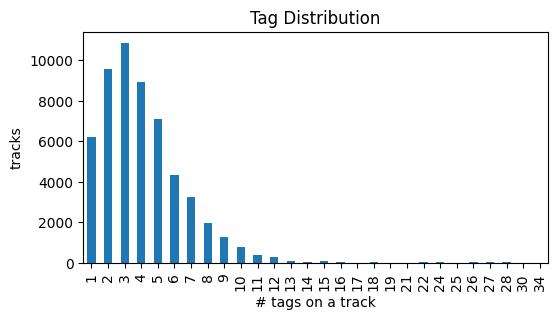

In [ ]:
auto["tag_list"] = auto["TAGS"].str.split("\t")
auto["tag_count"] = auto["tag_list"].apply(lambda xs: sum(1 for t in xs if t))
ax = auto["tag_count"].value_counts().sort_index().plot(kind="bar", figsize=(6,3))
ax.set_xlabel("# tags on a track"); ax.set_ylabel("tracks"); ax.set_title("Tag Distribution");


CREATING HEAT MAP FOR GENRE VS GENRE

In [ ]:
import pandas as pd

# keep only genre tags and go to long (one row per track–genre)
genre_long = (
    tracks_multi[["TRACK_ID", "tag_list"]]
      .explode("tag_list", ignore_index=True)
      .dropna(subset=["tag_list"])
)

# filter to genre namespace and extract the bare tag name
genre_long = genre_long[genre_long["tag_list"].str.startswith("genre---")].copy()
genre_long["genre"] = genre_long["tag_list"].str.split("---", n=1).str[1]
print(genre_long.shape)
genre_long.head(10)

(129831, 3)


,TRACK_ID,tag_list,genre
0,track_0000247,genre---pop,pop
1,track_0000247,genre---rock,rock
2,track_0000382,genre---classical,classical
4,track_0000383,genre---classical,classical
6,track_0000384,genre---classical,classical
8,track_0000386,genre---classical,classical
10,track_0000387,genre---classical,classical
12,track_0000388,genre---classical,classical
14,track_0000389,genre---classical,classical
16,track_0000390,genre---classical,classical


In [ ]:
Xg = (genre_long
      .assign(v=1)
      .pivot_table(index="TRACK_ID", columns="genre", values="v", fill_value=0))

In [ ]:
# C[g,h] = number of tracks that have both genre g and genre h
C = pd.DataFrame(Xg.T.values @ Xg.values, index=Xg.columns, columns=Xg.columns)

In [ ]:
def top_partners(genre: str, k: int = 10):
    return C.loc[genre].sort_values(ascending=False).head(k)

top_partners("electronic", k=10)  # try for any genre to see # of cooccurences


,electronic
genre,
electronic,14824.0
ambient,2881.0
experimental,2046.0
easylistening,1716.0
soundtrack,1697.0
dance,1530.0
techno,1338.0
pop,1301.0
house,1134.0


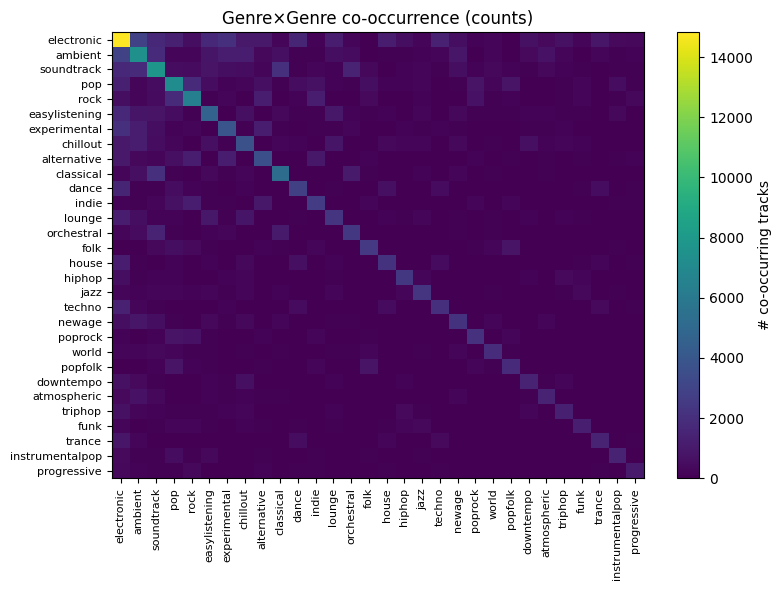

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def plot_cooc_heatmap(C, top_k=30, title="Genre×Genre co-occurrence (counts)"):
    """
    C: square DataFrame (index=columns=tags), integer counts.
    top_k: show the top_k most frequent tags by total co-occurrence.
    """
    # focus on the most active tags to keep the plot readable
    order = C.sum(axis=1).sort_values(ascending=False).head(top_k).index
    M = C.loc[order, order]

    fig, ax = plt.subplots(figsize=(8, 6))
    # normalize values to account for 'electronic' imbalance
    im = ax.imshow(M.values,
               aspect="auto",
               interpolation="nearest",
               )
    ax.set_xticks(range(len(order)))
    ax.set_yticks(range(len(order)))
    ax.set_xticklabels(order, rotation=90, fontsize=8)
    ax.set_yticklabels(order, fontsize=8)
    ax.set_title(title)
    cb = fig.colorbar(im, ax=ax)
    cb.set_label("# co-occurring tracks")
    plt.tight_layout()
    plt.show()

# Example:
plot_cooc_heatmap(C, top_k=30)


Tty normalizing to log scale

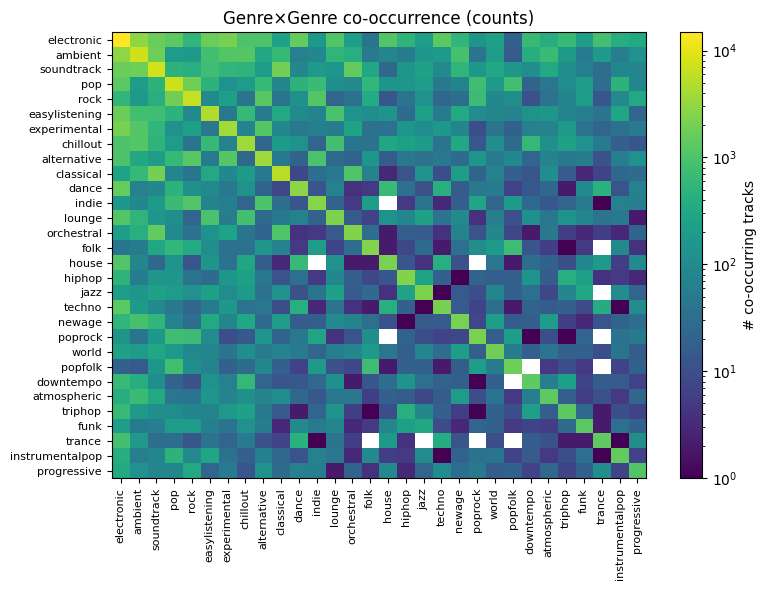

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def plot_cooc_heatmap(C, top_k=30, title="Genre×Genre co-occurrence (counts)"):
    """
    C: square DataFrame (index=columns=tags), integer counts.
    top_k: show the top_k most frequent tags by total co-occurrence.
    """
    # focus on the most active tags to keep the plot readable
    order = C.sum(axis=1).sort_values(ascending=False).head(top_k).index
    M = C.loc[order, order]

    fig, ax = plt.subplots(figsize=(8, 6))
    # normalize values to account for 'electronic' imbalance
    im = ax.imshow(M.values,
               aspect="auto",
               interpolation="nearest",
               norm=mcolors.LogNorm(vmin=1, vmax=M.values.max()))
    ax.set_xticks(range(len(order)))
    ax.set_yticks(range(len(order)))
    ax.set_xticklabels(order, rotation=90, fontsize=8)
    ax.set_yticklabels(order, fontsize=8)
    ax.set_title(title)
    cb = fig.colorbar(im, ax=ax)
    cb.set_label("# co-occurring tracks")
    plt.tight_layout()
    plt.show()

# Example:
plot_cooc_heatmap(C, top_k=30)
